# Lab 05: Polynomial Fitting
In the previous lab we discussed linear regression and the OLS estimator for solving the minimization of the RSS. As we
mentioned regression problems is a very wide family of settings an algorithms where we try to estimate the relation between
a set of explanatory variables and a **continuous** response (i.e. $\mathcal{Y}\in\mathbb{R^p}$). In the following lab we
will discuss another model called "Polynomial Fitting". 

Sometimes, the data (and the relation between the explanatory variables and response) can be described by some polynomial
of some degree. Here, we only focus on the case where it is a polynomial of a single variable. That is: 
$$ p_k\left(x\right)=\sum_{i=0}^{k}\alpha_i x_i^k\quad\alpha_1,\ldots,\alpha_k\in\mathbb{R} $$

So our hypothesis class is of the form:
$$ \mathcal{H}^k_{poly}=\left\{p_k|p_k\left(x\right)=\sum_{i=0}^{k}\alpha_i x_i^k\quad\alpha_1,\ldots,\alpha_k\in\mathbb{R}\right\} $$

Notice, that similar to linear regression, each hypothesis in the class is defined by a coefficients vector. Below are two
examples (simulated and real) for datasets where the relation between the explanatory variable and response is polynomial.


In [9]:
import sys
sys.path.append("../")
from utils import *

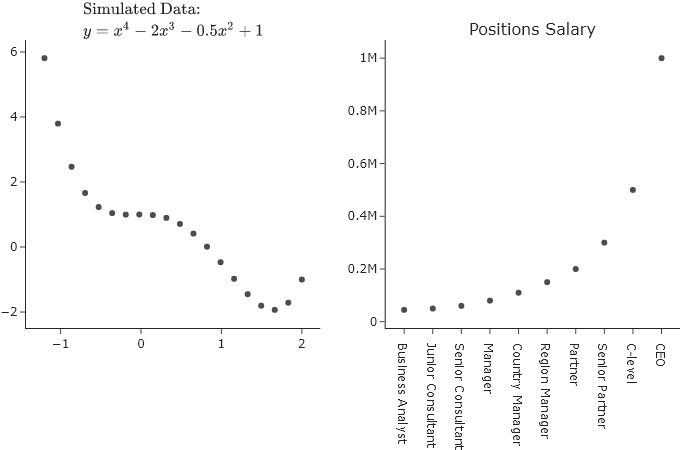

In [10]:
response = lambda x: x**4 - 2*x**3 - .5*x**2 + 1

x = np.linspace(-1.2, 2, 20)
y_ = response(x)

df = pd.read_csv("../data/Position_Salaries.csv", skiprows=2, index_col=0)
x2, y2 = df.index, df.Salary

fig = make_subplots(1, 2, subplot_titles=(r"$\text{Simulated Data:}\\y=x^4-2x^3-0.5x^2+1$", "Positions Salary"))
fig.add_trace(go.Scatter(x=x, y=y_, mode="markers", marker=dict(color="black", opacity=.7), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=x2, y=y2, mode="markers",marker=dict(color="black", opacity=.7), showlegend=False), row=1, col=2)
fig.show()



As we have discussed in class, solving a polynomial fitting problem can be done by first manipulating the input data,
such that we represent each sample $x_i\in\mathbb{R}$ as a vector $\mathbf{x}_i=\left(x^0,x^1,\ldots,x^k\right)$. Then,
we treat the data as a design matrix $\mathbf{X}\in\mathbb{R}^{m\times k}$ of a linear regression problem.

For the simulated dataset above, which is of a polynomial of degree 4, the design matrix looks as follows: 


In [11]:
from sklearn.preprocessing import PolynomialFeatures
m, k, X = 5, 4, x.reshape(-1, 1)
pd.DataFrame(PolynomialFeatures(k).fit_transform(X[:m]), 
             columns=[rf"$x^{{0}}$".format(i) for i in range(0, k+1)],
             index=[rf"$x_{{0}}$".format(i) for i in range(1, m+1)])



,$x^0$,$x^1$,$x^2$,$x^3$,$x^4$
$x_1$,1.0,-1.200000,1.440000,-1.728000,2.073600
$x_2$,1.0,-1.031579,1.064155,-1.097760,1.132426
$x_3$,1.0,-0.863158,0.745042,-0.643088,0.555087
$x_4$,1.0,-0.694737,0.482659,-0.335321,0.232960
$x_5$,1.0,-0.526316,0.277008,-0.145794,0.076734


Next, let us fit polynomials of different degrees and different noise properties to study how it influences the learned model.
We begin with the noise-less case where we fit for different values of $k$. As we increase $k$ we manage to fit a model
that describes the data in a better way, reflected by the decrease in the MSE.

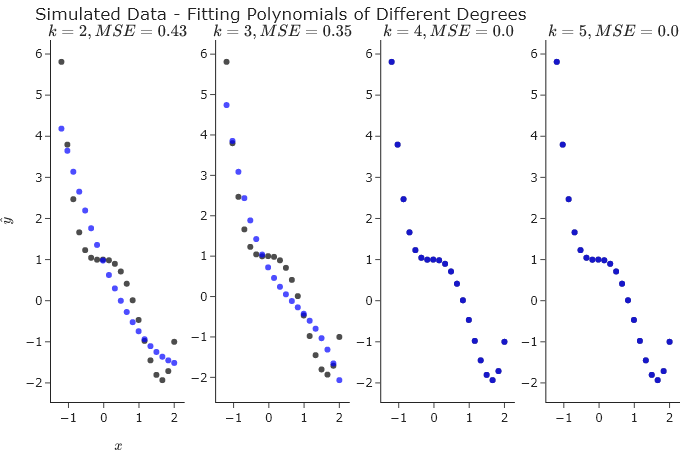

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

ks = [2, 3, 4, 5]
fig = make_subplots(1, 4, subplot_titles=list(ks))
for i, k in enumerate(ks):
    y_hat = make_pipeline(PolynomialFeatures(k), LinearRegression()).fit(X, y_).predict(X)
    
    fig.add_trace(go.Scatter(x=x, y=y_, mode="markers", name="Real Points",  marker=dict(color="black", opacity=.7), showlegend=False), row=1, col=i+1)
    fig.add_trace(go.Scatter(x=x, y=y_hat, mode="markers", name="Predicted Points",  marker=dict(color="blue", opacity=.7), showlegend=False), row=1, col=i+1)
    fig["layout"]["annotations"][i]["text"] = rf"$k={{0}}, MSE={{1}}$".format(k, round(np.mean((y_-y_hat)**2), 2))

fig.update_layout(title="Simulated Data - Fitting Polynomials of Different Degrees",
                  yaxis_title=r"$\widehat{y}$",
                  xaxis_title="r$x$",
                  height=300)
fig.show()


Once we find the right $k$ (which in our case is 4) we managed to fit a perfect model, after which, as we increase $k$, 
the additional coefficients will be zero.

In [4]:
coefs = {}
for k in ks:
    fit = make_pipeline(PolynomialFeatures(k), LinearRegression()).fit(X, y_)
    coefs[rf"$k={{{k}}}$"] = [round(c,3) for c in fit.steps[1][1].coef_]
pd.DataFrame.from_dict(coefs, orient='index', columns=[rf"$w_{{{i}}}$" for i in range(max(ks)+1)])


,$w_{0}$,$w_{1}$,$w_{2}$,$w_{3}$,$w_{4}$,$w_{5}$
$k={2}$,0.0,-2.153,0.465,NaN,NaN,NaN
$k={3}$,0.0,-1.668,0.945,-0.4,NaN,NaN
$k={4}$,0.0,-0.000,-0.500,-2.0,1.0,NaN
$k={5}$,0.0,0.000,-0.500,-2.0,1.0,0.0


Still fitting for different values of $k$, let us add some standard Gaussian noise (i.e. $\mathcal{N}\left(0,1\right)$).
This time we observe two things:
- Even for the correct $k=4$ model we are not able to achieve zero MSE.
- As we increase $4<k\rightarrow 7$ we manage to decrease the error more and more.

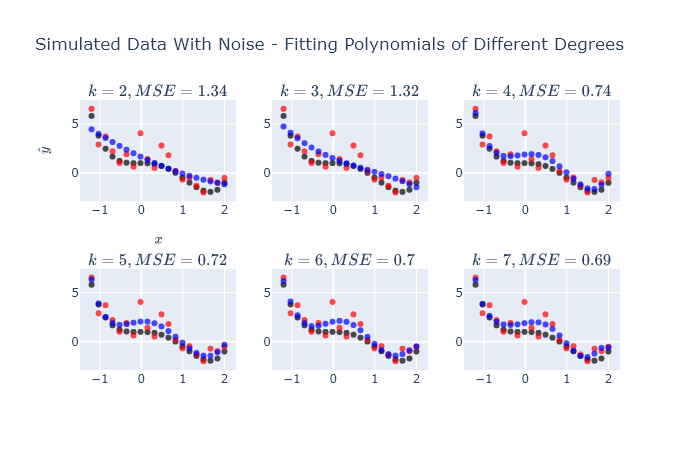

In [5]:
y = y_ + np.random.normal(size=len(y_))

ks = range(2, 8)
fig = make_subplots(2, 3, subplot_titles=list(ks))
for i, k in enumerate(ks):
    y_hat = make_pipeline(PolynomialFeatures(k), LinearRegression()).fit(X, y).predict(X)
    
    r,c = i//3+1, i%3+1 
    fig.add_trace(go.Scatter(x=x, y=y_, mode="markers", name="Real Points",  marker=dict(color="black", opacity=.7), showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Observed Points",  marker=dict(color="red", opacity=.7), showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=x, y=y_hat, mode="markers", name="Predicted Points",  marker=dict(color="blue", opacity=.7), showlegend=False), row=r, col=c)
    fig["layout"]["annotations"][i]["text"] = rf"$k={{0}}, MSE={{1}}$".format(k, round(np.mean((y-y_hat)**2), 2))

fig.update_layout(title="Simulated Data With Noise - Fitting Polynomials of Different Degrees",
                  yaxis_title=r"$\widehat{y}$",
                  xaxis_title="r$x$")
fig.show()


How is it that we are able to fit "better" models for $k$s larger than the true one? As we increase $k$ we enable the model
more "degrees of freedom" to try and adapt itself to the observed data. The higher $k$ the more the learner will "go after
the noise" and miss the real signal of the data. In other words, what we have just observed is what is known as **overfitting**.

Later in the course we will learn methods for detection and avoidance of overfitting.

Next, let us set $k=4$ (the true values) and study the outputted models when training over different noise levels. Though
we will only be changing the scale of the noise (i.e. the variance, $\sigma^2$), changing other properties such as it's
distribution is interesting too. As we would expect, as we increase the scale of the noise our error increases. We can
observe this also in a visual manner, where the fitted polynomial (in blue) less and less resembles the actual (in black).

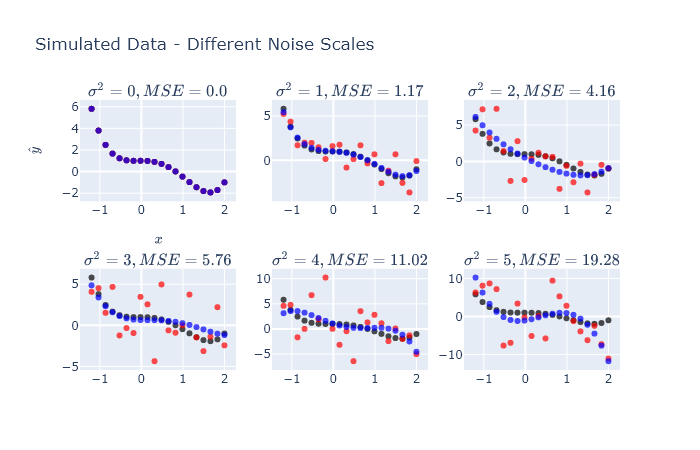

In [6]:

scales = range(6)
fig = make_subplots(2, 3, subplot_titles=list(map(str, scales)))
for i, s in enumerate(scales):
    y = y_ + np.random.normal(scale=s, size=len(y_))
    y_hat = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(X, y).predict(X)

    r,c = i//3+1, i%3+1
    fig.add_trace(go.Scatter(x=x, y=y_, mode="markers", name="Real Points",  marker=dict(color="black", opacity=.7), showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Observed Points",  marker=dict(color="red", opacity=.7), showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=x, y=y_hat, mode="markers", name="Predicted Points",  marker=dict(color="blue", opacity=.7), showlegend=False), row=r, col=c)
    fig["layout"]["annotations"][i]["text"] = rf"$\sigma^2={{0}}, MSE={{1}}$".format(s, round(np.mean((y-y_hat)**2), 2))

fig.update_layout(title="Simulated Data - Different Noise Scales",
                  yaxis_title=r"$\widehat{y}$",
                  xaxis_title="r$x$")
fig.show()



Lastly, let us check how the error is influenced by both $k$ and $\sigma^2$. For each value of $k$ and $\sigma^2$ we will
add noise drawm from $\mathcal{N}\left(0,\sigma^2\right)$ and then, based on the noisy data, let the learner select an
hypothesis from $\mathcal{H}_{poly}^k$. We repeat the process for each set of $\left(k,\sigma^2\right)$ 10 times and report
the mean MSE value. Results are seen in heatmap below: 


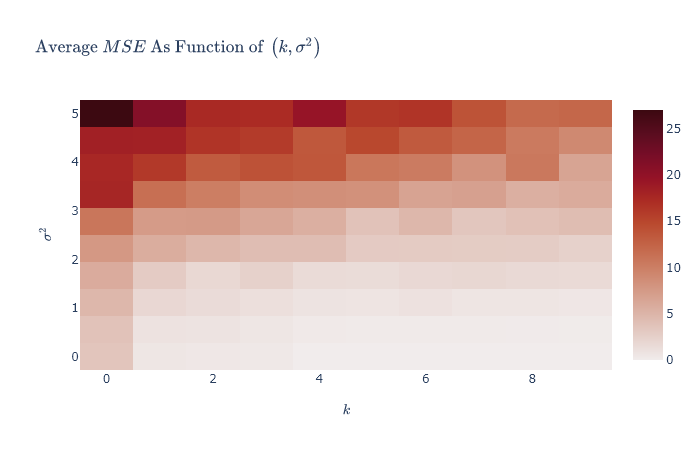

In [7]:
from sklearn.model_selection import ParameterGrid

df = []
for setting in ParameterGrid(dict(k=range(10), s=np.linspace(0, 5, 10), repetition=range(10))):
    y = y_ + np.random.normal(scale=setting["s"], size=len(y_))
    y_hat = make_pipeline(PolynomialFeatures(setting["k"]), LinearRegression()).fit(X, y).predict(X)
    
    df.append([setting["k"], setting["s"], np.mean((y-y_hat)**2)])
    
df = pd.DataFrame.from_records(df, columns=["k", "sigma","mse"]).groupby(["k","sigma"]).mean().reset_index()

go.Figure(go.Heatmap(x=df.k, y=df.sigma, z=df.mse, colorscale="amp"),
          layout=go.Layout(title=r"$\text{Average } MSE \text{ As Function of } \left(k,\sigma^2\right)$", 
                           xaxis_title=r"$k$ - Fitted Polynomial Degree",
                           yaxis_title=r"$\sigma^2$ - Noise Levels")).show()


We observe the following trends:
- As already seen before, for the noise-free data, once we reach the correct $k$ we achieve zero MSE.
- Across all values of $k$, as we increase $\sigma^2$ we get higher MSE values.
- For all noise levels, we manage to reduce MSE values by increasing $k$.

So, by choosing a **richer** hypothesis class (i.e. larger and that can express more functions - polynomials of higher
degree) we are able to choose an hypothesis that fits the **observed** data **better**, regardless to how noisy the data.
Try and think how would the above heatmap look if instead of calculating the MSE over the training samples (i.e train error)
we would have calculated it over a **new** set of test samples drawn from the same distribution.

Use the below code to create a test set. Change the snippet above such that reported error is a test error. Do not forget
to add the noise (that depends on $\sigma^2$) to the test data.

In [8]:
testX = np.linspace(-1.2, 2, 40)[1::2].reshape(-1,1)
testY = response(testX)
